<a href="https://colab.research.google.com/github/damifts/pytorch-mnist-from-scratch/blob/main/notebooks/mnist_mlp_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#FIRST NEURAL NETWORK


In [ ]:
from torchvision.datasets import mnist
import torch
import math

In [ ]:
train = mnist.MNIST(root='./data/', download=True, train=True)
test = mnist.MNIST(root='./data/', download=True, train=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 11.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 335kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.11MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.0MB/s]


In [ ]:
x_train = train.data
y_train = train.targets
x_test = test.data
y_test = test.targets

In [ ]:
# reshape dei dati perché il MLP non vuole array 28 x 28, ma vuole array unidimensionali
# normalizzazione dei dati dividendo per 255

In [ ]:
# creo un minibatch

In [ ]:
# W1, b1, W2, b2. I W hanno shape (input, output) e i b hanno dimensione (output,)
# tutti questi parametri richiedono il gradiente (va specificato in fase di creazione)

In [ ]:
def relu(x):
  """ Applica la funzione relu al tensore x

  Args:
    x: un tensore

  Returns:
    un tensore con lo stesso shape di x
  """
  return torch.where(x > 0, x, 0.)

In [ ]:
def cross_entropy(y_pred, y_true):
  """ Calcola la loss cross entropy

  Args:
    y_pred: un tensore di shape (batch_size, C) dove C è il numero delle classi
    y_true: un tensore di shape (batch_size) contenente gli indici delle classi
  """
  probs = y_pred[torch.arange(0, y_pred.shape[0]), y_true] # probs shape (batch_size,)
  return -torch.log(probs).mean()


In [ ]:
def softmax(x):
  """ Applica la funzione softmax al tensore x

  Args:
    x: un tensore di shape (batch_size, n)

  Returns:
    un tensore con lo stesso shape di x"""

  x = x - x.max(dim=1, keepdim=True).values

  exp = torch.exp(x)
  return exp / exp.sum(dim=1, keepdim=True)

In [ ]:
class NN:
  def __init__(self, device="cpu"):
    self.W1 = torch.randn(size=(784, 50), device=device) / math.sqrt(784)
    self.W1.requires_grad_()
    self.b1 = torch.zeros(size=(50,), requires_grad=True, device=device)
    self.W2 = torch.randn(size=(50, 10), device=device) / math.sqrt(50)
    self.W2.requires_grad_()
    self.b2 = torch.zeros(size=(10,), requires_grad=True, device=device)

  def forward(self, x):
    """ Prende in input un minibtach x e restituisce le predizioni della rete

    Args:
      x: un tensore di shape (batch_size, input_dim=784)

    Returns:
      un tensore di shape (batch_size, output_dim=10)
    """
    x = x@self.W1 + self.b1
    x = relu(x)
    x = x@self.W2 + self.b2
    return softmax(x)


In [ ]:
def accuracy(model, x, y):
  """ Calcola l'accuracy della rete
  """
  y_pred = model.forward(x)
  y_pred = y_pred.argmax(dim=1) # ottengo le classi dalle probabilità
  return (y_pred == y).float().mean()

In [ ]:
x_train = x_train.reshape(-1, 28*28) / 255. # reshape e normalizzazione
x_test = x_test.reshape(-1, 28*28) / 255. # reshape e normalizzazione

In [ ]:
BATCH_SIZE = 32
LEARNING_RATE = 1e-2
EPOCHS = 100
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# creo la rete
nn = NN(device=DEVICE)

for epoch in range(EPOCHS):
  losses = []
  # rimescolo le immagini
  perm = torch.randperm(x_train.shape[0])
  x_train = x_train[perm]
  y_train = y_train[perm]
  # cicliamo sui minibatch
  for idx in range(0, x_train.shape[0], BATCH_SIZE):
    x_batch = x_train[idx:idx+BATCH_SIZE]
    y_batch = y_train[idx:idx+BATCH_SIZE]

    # la rete elabora le immagini
    y_pred = nn.forward(x_batch.to(DEVICE)) # y_pred shape (BATCH_SIZE, 10)

    # calcolo il costo
    loss = cross_entropy(y_pred, y_batch)
    losses.append(loss.item())

    # backpropagation
    loss.backward()

    # facciamo un passo di discesa del gradiente
    with torch.no_grad():
      nn.W1 -= LEARNING_RATE * nn.W1.grad
      nn.b1 -= LEARNING_RATE * nn.b1.grad
      nn.W2 -= LEARNING_RATE * nn.W2.grad
      nn.b2 -= LEARNING_RATE * nn.b2.grad

      # azzero i gradienti
      nn.W1.grad.zero_()
      nn.b1.grad.zero_()
      nn.W2.grad.zero_()
      nn.b2.grad.zero_()

  # fine dell'epoca
  train_acc = accuracy(nn, x_train.to(DEVICE), y_train.to(DEVICE))
  test_acc = accuracy(nn, x_test.to(DEVICE), y_test.to(DEVICE))

  print(f"Epoch {epoch+1}/{EPOCHS}")
  print(f"Loss: {torch.tensor(losses).mean()}")
  print(f"{train_acc=}")
  print(f"{test_acc=}")

Epoch 1/100
Loss: 0.7398629188537598
train_acc=tensor(0.8918, device='cuda:0')
test_acc=tensor(0.8980, device='cuda:0')
Epoch 2/100
Loss: 0.35935088992118835
train_acc=tensor(0.9087, device='cuda:0')
test_acc=tensor(0.9127, device='cuda:0')
Epoch 3/100
Loss: 0.30952388048171997
train_acc=tensor(0.9181, device='cuda:0')
test_acc=tensor(0.9209, device='cuda:0')
Epoch 4/100
Loss: 0.2810707688331604
train_acc=tensor(0.9258, device='cuda:0')
test_acc=tensor(0.9264, device='cuda:0')
Epoch 5/100
Loss: 0.2603572905063629
train_acc=tensor(0.9307, device='cuda:0')
test_acc=tensor(0.9311, device='cuda:0')
Epoch 6/100
Loss: 0.24343271553516388
train_acc=tensor(0.9347, device='cuda:0')
test_acc=tensor(0.9343, device='cuda:0')
Epoch 7/100
Loss: 0.22931386530399323
train_acc=tensor(0.9383, device='cuda:0')
test_acc=tensor(0.9377, device='cuda:0')
Epoch 8/100
Loss: 0.2168710082769394
train_acc=tensor(0.9415, device='cuda:0')
test_acc=tensor(0.9394, device='cuda:0')
Epoch 9/100
Loss: 0.2057415843009948

# Predizioni

In [ ]:
def predict(model, x):
  """ Predizione della rete
  """
  y_pred = model.forward(x)
  y_pred = y_pred.argmax(dim=1) # ottengo le classi dalle probabilità
  return y_pred

In [ ]:
y_test_pred = predict(nn, x_test.to(DEVICE))

In [ ]:
(y_test_pred.to(DEVICE) == y_test.to(DEVICE)).float().mean()

tensor(0.9755, device='cuda:0')

# Le predizioni peggiori

In [ ]:
y_test_probs = nn.forward(x_test.to(DEVICE))

In [ ]:
y_test_correct_probs = y_test_probs[torch.arange(0, y_test_probs.shape[0]), y_test]

In [ ]:
worst_12 = torch.argsort(y_test_correct_probs)[:12]

In [ ]:
import matplotlib.pyplot as plt

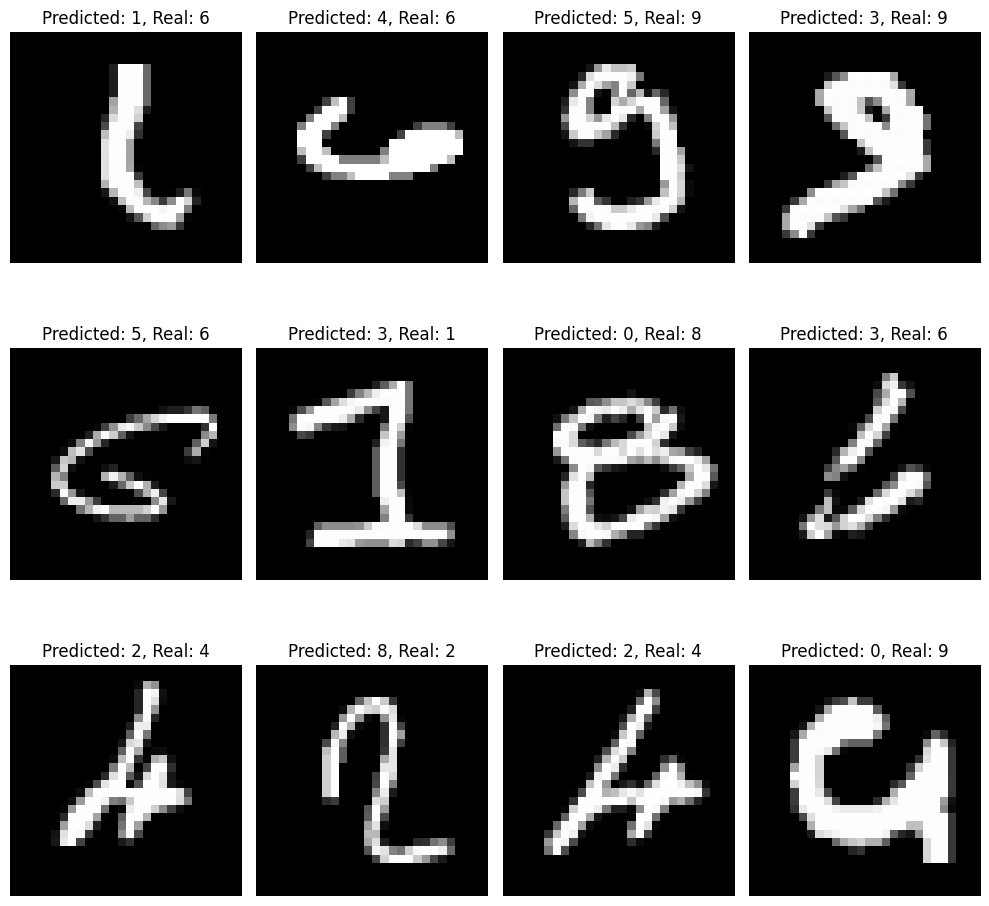

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(10, 10))

for i, ax in enumerate(axes.flatten()):
  ax.imshow(x_test[worst_12[i]].reshape(28, 28), cmap="gray")
  ax.set_title(f"Predicted: {y_test_pred[worst_12[i]]}, Real: {y_test[worst_12[i]]}")
  ax.axis("off")

plt.tight_layout()
plt.show()